In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler, MinMaxScaler



In [54]:
# Load Data


In [55]:
ppi_df = pd.read_csv('../Data/filtered_PPI.csv', delimiter=',')
def find_common_prefix(strings):
    if not strings:
        return ""
    prefix = strings[0]
    for string in strings[1:]:
        while not string.startswith(prefix):
            prefix = prefix[:-1]
            if not prefix:
                return ""
    return prefix


protein1_prefix = find_common_prefix(ppi_df['protein1'].tolist())
protein2_prefix = find_common_prefix(ppi_df['protein2'].tolist())
print("Common prefix in 'protein1':", protein1_prefix)
print("Common prefix in 'protein2':", protein2_prefix)
ppi_df['protein1'] = ppi_df['protein1'].str.replace(protein1_prefix, '', regex=False)
ppi_df['protein2'] = ppi_df['protein2'].str.replace(protein1_prefix, '', regex=False)
scaler = MinMaxScaler()
ppi_df['score_scaled'] = scaler.fit_transform(ppi_df[['combined_score']])

Common prefix in 'protein1': 9606.ENSP00000
Common prefix in 'protein2': 9606.ENSP00000


In [56]:
ppi_df.head()

,protein1,protein2,combined_score,score_scaled
0,000233,310226,648,0.095361
1,000233,248901,618,0.018041
2,000233,158762,825,0.551546
3,000233,239690,622,0.028351
4,000233,357048,718,0.275773


In [76]:
G = nx.Graph()


In [81]:
for row in ppi_df.head(5000).iterrows():
    G.add_edge(row[1]['protein1'], row[1]['protein2'], weight= round(row[1]['score_scaled'], 2))

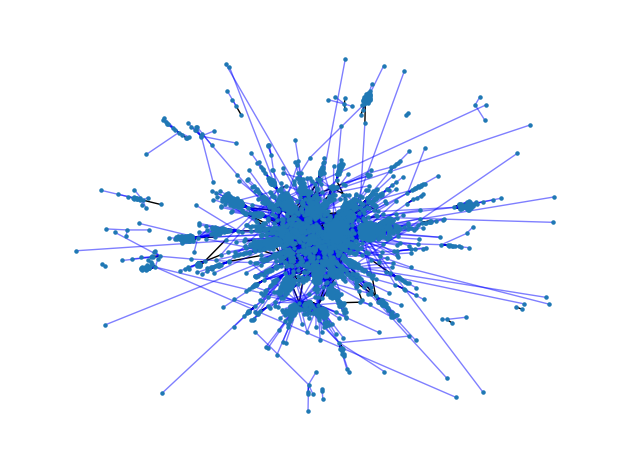

In [83]:
elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 0.5]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 0.5]

pos = nx.spring_layout(G, seed=7)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=5)

# edges
nx.draw_networkx_edges(G, pos, edgelist=elarge, width=1)
nx.draw_networkx_edges(
    G, pos, edgelist=esmall, width=1, alpha=0.5, edge_color="b"
)

# node labels
#nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
# edge weight labels

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()